In [1]:
from pathlib import Path

%pip install --quiet --disable-pip-version-check numpy==2.5.3
%pip install --quiet --disable-pip-version-check pandas==3.0.6
%pip install --quiet --disable-pip-version-check scikit-learn==1.9.1
%pip install --quiet --disable-pip-version-check matplotlib==3.11.2
%pip install --quiet --disable-pip-version-check threadpoolctl==3.7.0

import io
import re
import zipfile
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

In [2]:
SOURCE = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
END_MONTH = "2026-08"
WINDOW = 12
MIN_TRAIN = 60
TRAIN_MONTHS = 120
SEED = 42
REFRESH_DATA = False

DATA = Path("data")
OUTPUT = Path("results")
DATA.mkdir(exist_ok=True)
OUTPUT.mkdir(exist_ok=True)

LOWER = "Lower factor volatility"
HIGHER = "Higher factor volatility"

In [3]:
def load_monthly(filename, columns):
    path = DATA / filename
    if REFRESH_DATA or not path.exists():
        with urlopen(SOURCE + filename, timeout=30) as response:
            content = response.read()
    else:
        content = path.read_bytes()
    with zipfile.ZipFile(io.BytesIO(content)) as archive:
        member = next(name for name in archive.namelist() if name.lower().endswith(".csv"))
        lines = archive.read(member).decode("utf-8-sig").splitlines()
    start = next(i for i, line in enumerate(lines) if re.match(r"^\s*\d{6}\s*,", line))
    end = start
    while end < len(lines) and re.match(r"^\s*\d{6}\s*,", lines[end]):
        end += 1
    frame = pd.read_csv(io.StringIO("\n".join(lines[start - 1:end])), index_col=0)
    frame.columns = frame.columns.str.strip()
    frame.index = pd.to_datetime(frame.index.astype(str).str.strip(), format="%Y%m").to_period("M")
    if not frame.index.is_unique:
        raise ValueError("The source contains duplicate months.")
    frame = frame[columns].apply(pd.to_numeric).replace([-99.99, -999], np.nan) / 100
    path.write_bytes(content)
    return frame.sort_index()

In [4]:
value_profit = load_monthly("Emerging_5_Factors_CSV.zip", ["HML", "RMW"])
momentum = load_monthly("Emerging_MOM_Factor_CSV.zip", ["WML"])
factors = value_profit.join(momentum, how="inner").loc[:END_MONTH]
factors = factors.loc[factors.dropna().index.min():]
factors = factors.reindex(pd.period_range(factors.index.min(), factors.index.max(), freq="M"))
if not np.isfinite(factors.to_numpy()).all():
    raise ValueError("The factor history contains missing or invalid returns.")
factors.columns = ["Value", "Profitability", "Momentum"]
factors.index = factors.index.to_timestamp("M")
factors.index.name = "Month"

print("Emerging markets: monthly long-short factor returns (%)")
display((factors.tail(6) * 100).round(2))

Emerging markets: monthly long-short factor returns (%)


,Value,Profitability,Momentum
Month,,,
2026-03-31,-0.67,-0.59,-5.03
2026-04-30,-4.33,2.73,12.84
2026-05-31,1.77,4.70,9.58
2026-06-30,1.37,2.07,0.36
2026-07-31,6.70,-0.54,-16.84
2026-08-31,-3.27,-2.45,8.02


In [5]:
features = pd.DataFrame(index=factors.index)
features["Factor volatility"] = factors.rolling(WINDOW).std().mean(axis=1) * np.sqrt(12)
pairs = [("Value", "Profitability"), ("Value", "Momentum"), ("Profitability", "Momentum")]
correlations = [factors[left].rolling(WINDOW).corr(factors[right]) for left, right in pairs]
features["Factor correlation"] = pd.concat(correlations, axis=1).mean(axis=1, skipna=False)
features = features.dropna()
if len(features) <= MIN_TRAIN:
    raise ValueError("More monthly history is needed to fit the model.")

In [6]:
rows = []
with threadpool_limits(limits=1):
    for i in range(MIN_TRAIN, len(features)):
        training = features.iloc[max(0, i - TRAIN_MONTHS):i]
        current = features.iloc[[i]]
        scaler = StandardScaler().fit(training)
        model = GaussianMixture(n_components=2, n_init=5, max_iter=500, reg_covar=0.0001, random_state=SEED)
        model.fit(scaler.transform(training))
        if not model.converged_:
            raise ValueError("The regime model did not converge.")
        centers = scaler.inverse_transform(model.means_)
        lower_state, higher_state = np.argsort(centers[:, 0])
        labels = {lower_state: LOWER, higher_state: HIGHER}
        state = model.predict(scaler.transform(current))[0]
        rows.append({
            "Month": current.index[0],
            "Regime": labels[state],
            "Training through": training.index[-1],
            "Factor volatility %": current.iloc[0]["Factor volatility"] * 100,
            "Factor correlation": current.iloc[0]["Factor correlation"],
        })

regimes = pd.DataFrame(rows).set_index("Month")
previous = regimes["Regime"].shift(1)
regimes["Changed"] = previous.notna() & regimes["Regime"].ne(previous)
changes = regimes.loc[regimes["Changed"]].copy()
changes.insert(0, "Previous regime", previous.loc[changes.index])

In [7]:
latest = regimes.iloc[-1]
display(pd.Series({
    "Data month": regimes.index[-1].strftime("%B %Y"),
    "Regime": latest["Regime"],
    "Changed from previous month": bool(latest["Changed"]),
    "Factor volatility %": round(latest["Factor volatility %"], 2),
    "Factor correlation": round(latest["Factor correlation"], 3),
}, name="Latest result").to_frame())
display(regimes.tail(12).round(3))

,Latest result
Data month,August 2026
Regime,Higher factor volatility
Changed from previous month,False
Factor volatility %,14.59
Factor correlation,-0.1


C:\Users\Arian\AppData\Local\Temp\ipykernel_19900\172778139.py:9: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(regimes.tail(12).round(3))


,Regime,Training through,Factor volatility %,Factor correlation,Changed
Month,,,,,
2025-09-30,Lower factor volatility,2025-08-31,5.417,0.102,False
2025-10-31,Lower factor volatility,2025-09-30,5.461,0.175,False
2025-11-30,Lower factor volatility,2025-10-31,5.581,0.152,False
2025-12-31,Lower factor volatility,2025-11-30,5.539,0.228,False
2026-01-31,Lower factor volatility,2025-12-31,6.644,0.183,False
2026-02-28,Lower factor volatility,2026-01-31,6.436,0.144,False
2026-03-31,Lower factor volatility,2026-02-28,6.792,0.287,False
2026-04-30,Higher factor volatility,2026-03-31,8.777,0.017,True
2026-05-31,Higher factor volatility,2026-04-30,9.818,0.181,False


In [8]:
display(changes.tail(10).round(3))

C:\Users\Arian\AppData\Local\Temp\ipykernel_19900\810778489.py:1: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(changes.tail(10).round(3))


,Previous regime,Regime,Training through,Factor volatility %,Factor correlation,Changed
Month,,,,,,
2022-10-31,Higher factor volatility,Lower factor volatility,2022-09-30,7.091,0.191,True
2022-12-31,Lower factor volatility,Higher factor volatility,2022-11-30,9.262,0.030,True
2023-09-30,Higher factor volatility,Lower factor volatility,2023-08-31,8.521,-0.263,True
2023-10-31,Lower factor volatility,Higher factor volatility,2023-09-30,8.254,-0.256,True
2023-11-30,Higher factor volatility,Lower factor volatility,2023-10-31,6.006,-0.212,True
2024-02-29,Lower factor volatility,Higher factor volatility,2024-01-31,5.232,-0.011,True
2024-12-31,Higher factor volatility,Lower factor volatility,2024-11-30,6.943,0.232,True
2025-01-31,Lower factor volatility,Higher factor volatility,2024-12-31,6.030,0.153,True
2025-04-30,Higher factor volatility,Lower factor volatility,2025-03-31,6.531,0.314,True


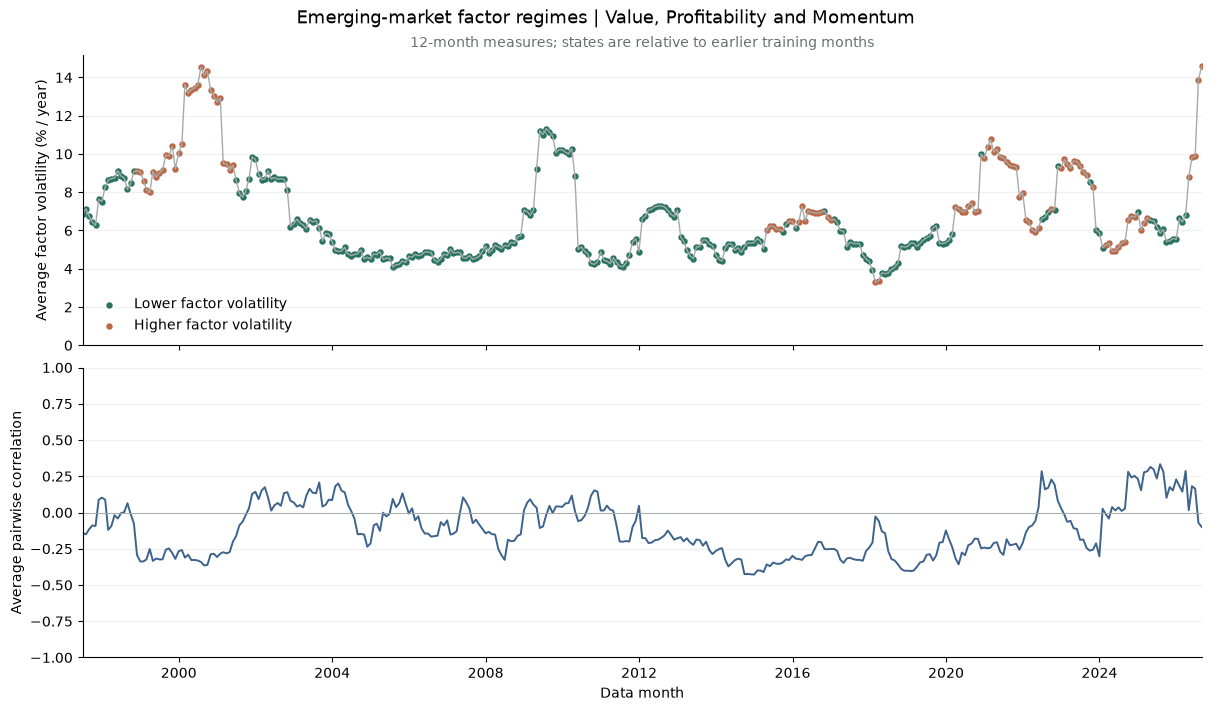

In [9]:
colors = {LOWER: "#28745e", HIGHER: "#bb6847"}
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, layout="constrained")
axes[0].plot(regimes.index, regimes["Factor volatility %"], color="#a5aba8", linewidth=1)
for label, color in colors.items():
    selected = regimes["Regime"].eq(label)
    axes[0].scatter(regimes.index[selected], regimes.loc[selected, "Factor volatility %"], s=13, color=color, label=label)
axes[0].set_ylabel("Average factor volatility (% / year)")
axes[0].set_ylim(bottom=0)
axes[0].legend(frameon=False, loc="lower left")
axes[1].plot(regimes.index, regimes["Factor correlation"], color="#3d638d", linewidth=1.4)
axes[1].axhline(0, color="#a5aba8", linewidth=0.7)
axes[1].set_ylim(-1, 1)
axes[1].set_ylabel("Average pairwise correlation")
axes[1].set_xlabel("Data month")
axes[1].set_xlim(regimes.index[0], regimes.index[-1])
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
fig.suptitle("Emerging-market factor regimes | Value, Profitability and Momentum", fontsize=13)
axes[0].set_title(f"{WINDOW}-month measures; states are relative to earlier training months", fontsize=10, color="#64716b")
fig.savefig(OUTPUT / "regime_changes.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
factors.to_csv(OUTPUT / "factor_returns.csv", date_format="%Y-%m-%d")
regimes.to_csv(OUTPUT / "regimes.csv", date_format="%Y-%m-%d")
changes.to_csv(OUTPUT / "regime_changes.csv", date_format="%Y-%m-%d")

Using Kenneth French's Value, Profitability and Momentum returns, the model identified 27 regime changes over 351 months. The latest month, August 2026, was labelled higher factor volatility, with average annualized factor volatility of 14.59% and average pairwise correlation of -0.10. The last change was in April 2026. Volatility and correlation tell us different things, so we need to look at both. This is a description of the published monthly data, not evidence that the model predicts crises or that changing the portfolio at these points would reduce losses.